In [1]:
#导入相关依赖库
import  os
import numpy as np
from matplotlib import pyplot as plt

import mindspore as ms
#nn中有各种神经网络层如：Dense，ReLu
#context模块用于设置实验环境和实验设备
#load_checkpoint, load_param_into_net将模型参数存入parameter的字典中，并将参数加载到网络中
from mindspore import nn, context, load_checkpoint, load_param_into_net, Tensor
#dataset模块用于处理数据形成数据集
import mindspore.dataset as ds
#transforms模块用于转换数据类型
#vision模块用于转换图像，这是一个基于opencv的高级API
from mindspore.dataset import transforms, vision
#Model用于创建模型对象，完成网络搭建和编译，并用于训练和评估;
#LossMonitor可以在训练过程中返回LOSS值作为监控指标；
#导入Accuracy作为评价指标。
from mindspore.train import Model, LossMonitor, Accuracy, CheckpointConfig, ModelCheckpoint
from mindspore.dataset import MnistDataset
# from download import download
# url = "https://mindspore-website.obs.cn-north-4.myhuaweicloud.com/notebook/datasets/MNIST_Data.zip"
# path = download(url, "./", kind="zip", replace=True)

/usr/local/Ascend/ascend-toolkit/7.0.RC1/python/site-packages/tbe/tvm/contrib/ccec.py:766: DeprecationWarning: invalid escape sequence \L
  if not dirpath.find("AppData\Local\Temp"):
/usr/local/Ascend/ascend-toolkit/latest/python/site-packages/tbe/dsl/classifier/transdata/transdata_classifier.py:222: DeprecationWarning: invalid escape sequence \B
  """
/usr/local/Ascend/ascend-toolkit/latest/python/site-packages/tbe/dsl/unify_schedule/vector/transdata/common/graph/transdata_graph_info.py:140: DeprecationWarning: invalid escape sequence \c
  """
/home/ma-user/anaconda3/envs/MindSpore/lib/python3.9/site-packages/numpy/core/getlimits.py:499: UserWarning: The value of the smallest subnormal for <class 'numpy.float64'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/home/ma-user/anaconda3/envs/MindSpore/lib/python3.9/site-packages/numpy/core/getlimits.py:499: UserWarning: The value of the smallest subnormal for <class 'numpy.float32'> type is zero.
  setattr(self, word, 

In [2]:
# train_dataset = MnistDataset('MNIST_Data/train')
# test_dataset = MnistDataset('MNIST_Data/test')

In [3]:
# print(train_dataset.get_col_names())

In [4]:
# image=train_dataset.create_dict_iterator().__next__()
# image=next(train_dataset.create_dict_iterator())
# print(type(image))
# print('图像长/宽/通道数：',image['image'].shape)
# #一共10类，用0-9的数字表达类别。
# print('一张图像的标签样式：',image['label'])

# print(image)

In [2]:
DATA_DIR_TRAIN = "./MNIST_Data/train" # 训练集信息
DATA_DIR_TEST = "./MNIST_Data/test" # 测试集信息

In [3]:
def create_dataset(training=True, batch_size=64, resize=(28, 28),rescale=1/255, shift=-0.5):
    ds = ms.dataset.MnistDataset(DATA_DIR_TRAIN if training else DATA_DIR_TEST, shuffle=True)

    #定义改变形状、归一化和更改图片维度的操作。
    trans_transform = [
        #改为（28,28）的形状
        vision.Resize(resize),
        #rescale方法可以对数据集进行归一化和标准化操作，这里就是将像素值归一到0和1之间，shift参数可以让值域偏移至-0.5和0.5之间
        vision.Rescale(rescale, shift),
        #由高度、宽度、深度改为深度、高度、宽度
        vision.HWC2CHW(),
    ]
    label_transform = transforms.TypeCast(ms.int32)

    # 利用map操作对原数据集进行调整
    ds = ds.map(operations=trans_transform, input_columns=["image"])
    ds = ds.map(operations=label_transform, input_columns=["label"])

    ds = ds.batch(batch_size, drop_remainder=True)

    return ds


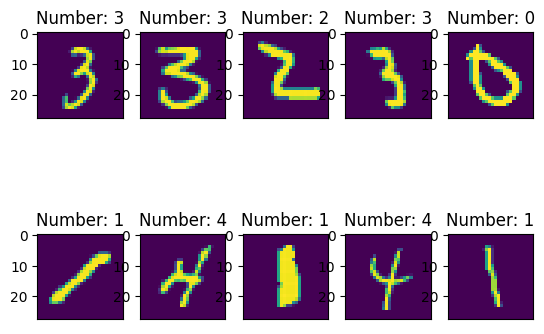

In [4]:
dataset_show = create_dataset(training=True)
data = dataset_show.create_dict_iterator().__next__()
images = data['image'].asnumpy()
labels = data['label'].asnumpy()

for i in range(1,11):
    plt.subplot(2, 5, i)
    #利用squeeze方法去掉多余的一个维度
    plt.imshow(np.squeeze(images[i]))
    plt.title('Number: %s' % labels[i])
    plt.xticks([])
plt.show()

In [5]:
train_dataset = create_dataset(True, 64)
test_dataset = create_dataset(False, 64)

In [6]:
for image, label in test_dataset.create_tuple_iterator():
    print(f"Shape of image [N, C, H, W]: {image.shape} {image.dtype}")
    print(f"Shape of label: {label.shape} {label.dtype}")
    break

Shape of image [N, C, H, W]: (64, 1, 28, 28) Float32
Shape of label: (64,) Int32


In [7]:
for data in test_dataset.create_dict_iterator():
    print(f"Shape of image [N, C, H, W]: {data['image'].shape} {data['image'].dtype}")
    print(f"Shape of label: {data['label'].shape} {data['label'].dtype}")
    break


Shape of image [N, C, H, W]: (64, 1, 28, 28) Float32
Shape of label: (64,) Int32


In [8]:
# Define model
class Network(nn.Cell):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.dense_relu_sequential = nn.SequentialCell(
            nn.Dense(28*28, 512),
            nn.ReLU(),
            nn.Dense(512, 512),
            nn.ReLU(),
            nn.Dense(512, 512),
            nn.ReLU(),
            nn.Dense(512, 10)
        )

    def construct(self, x):
        x = self.flatten(x)
        logits = self.dense_relu_sequential(x)
        return logits

model = Network()
print(model)


[WARNING] DEVICE(2659,ffff899380b0,python):2025-07-05-19:21:59.422.443 [mindspore/ccsrc/plugin/device/ascend/hal/device/ascend_runtime_manager.cc:46] GetAscendRuntime] No ascend runtime creator for AscendVM with device id 0
/usr/local/Ascend/ascend-toolkit/latest/python/site-packages/tbe/dsl/unify_schedule/extract_image_patches_without_cbuf_schedule.py:317: SyntaxWarning: "is not" with a literal. Did you mean "!="?
  if _ is not 1:
/usr/local/Ascend/ascend-toolkit/latest/python/site-packages/tbe/dsl/unify_schedule/extract_image_patches_without_cbuf_schedule.py:317: SyntaxWarning: "is not" with a literal. Did you mean "!="?
  if _ is not 1:
/usr/local/Ascend/ascend-toolkit/latest/python/site-packages/tbe/dsl/unify_schedule/extract_image_patches_without_cbuf_schedule.py:317: SyntaxWarning: "is not" with a literal. Did you mean "!="?
  if _ is not 1:
/usr/local/Ascend/ascend-toolkit/latest/python/site-packages/tbe/dsl/unify_schedule/extract_image_patches_without_cbuf_schedule.py:317: Synt

Network<
  (flatten): Flatten<>
  (dense_relu_sequential): SequentialCell<
    (0): Dense<input_channels=784, output_channels=512, has_bias=True>
    (1): ReLU<>
    (2): Dense<input_channels=512, output_channels=512, has_bias=True>
    (3): ReLU<>
    (4): Dense<input_channels=512, output_channels=512, has_bias=True>
    (5): ReLU<>
    (6): Dense<input_channels=512, output_channels=10, has_bias=True>
    >
  >


In [9]:
# Instantiate loss function and optimizer
# loss_fn = nn.CrossEntropyLoss()
loss_fn = nn.SoftmaxCrossEntropyWithLogits(sparse=True, reduction="mean")
optimizer = nn.SGD(model.trainable_params(), 1e-2)

# 1. Define forward function
def forward_fn(data, label):
    logits = model(data)
    loss = loss_fn(logits, label)
    return loss, logits

# 2. Get gradient function
grad_fn = ms.value_and_grad(forward_fn, None, optimizer.parameters, has_aux=True)

# 3. Define function of one-step training
def train_step(data, label):
    (loss, _), grads = grad_fn(data, label)
    optimizer(grads)
    return loss

def train(model, dataset):
    size = dataset.get_dataset_size()
    model.set_train()
    for batch, (data, label) in enumerate(dataset.create_tuple_iterator()):
        loss = train_step(data, label)

        if batch % 100 == 0:
            loss, current = loss.asnumpy(), batch
            print(f"loss: {loss:>7f}  [{current:>3d}/{size:>3d}]")


In [10]:
def test(model, dataset, loss_fn):
    num_batches = dataset.get_dataset_size()
    model.set_train(False)
    total, test_loss, correct = 0, 0, 0
    for data, label in dataset.create_tuple_iterator():
        pred = model(data)
        total += len(data)
        test_loss += loss_fn(pred, label).asnumpy()
        correct += (pred.argmax(1) == label).asnumpy().sum()
    test_loss /= num_batches
    correct /= total
    print(f"Test: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")


In [11]:
epochs = 3
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train(model, train_dataset)
    test(model, test_dataset, loss_fn)
print("Done!")


Epoch 1
-------------------------------
loss: 2.300441  [  0/937]
loss: 2.284201  [100/937]
loss: 2.272633  [200/937]
loss: 2.238766  [300/937]
loss: 2.195860  [400/937]
loss: 2.121083  [500/937]
loss: 1.864760  [600/937]
loss: 1.498213  [700/937]
loss: 1.332962  [800/937]
loss: 1.103628  [900/937]
Test: 
 Accuracy: 70.9%, Avg loss: 0.983521 

Epoch 2
-------------------------------
loss: 1.077213  [  0/937]
loss: 0.834473  [100/937]
loss: 0.797543  [200/937]
loss: 0.687977  [300/937]
loss: 0.676637  [400/937]
loss: 0.538326  [500/937]
loss: 0.404490  [600/937]
loss: 0.492405  [700/937]
loss: 0.492079  [800/937]
loss: 0.423006  [900/937]
Test: 
 Accuracy: 87.2%, Avg loss: 0.438409 

Epoch 3
-------------------------------
loss: 0.462349  [  0/937]
loss: 0.363119  [100/937]
loss: 0.406840  [200/937]
loss: 0.348887  [300/937]
loss: 0.408750  [400/937]
loss: 0.229300  [500/937]
loss: 0.225715  [600/937]
loss: 0.309816  [700/937]
loss: 0.365208  [800/937]
loss: 0.284226  [900/937]
Test: 
 

In [12]:
# Save checkpoint
ms.save_checkpoint(model, "model.ckpt")
print("Saved Model to model.ckpt")


Saved Model to model.ckpt


In [13]:
# Instantiate a random initialized model
model = Network()
# Load checkpoint and load parameter to model
param_dict = ms.load_checkpoint("model.ckpt")
param_not_load, _ = ms.load_param_into_net(model, param_dict)
print(param_not_load)


[]


In [14]:
model.set_train(False)
for data, label in test_dataset:
    pred = model(data)
    predicted = pred.argmax(1)
    print(f'Predicted: "{predicted[:10]}", Actual: "{label[:10]}"')
    break


Predicted: "[6 7 6 3 5 7 3 8 2 8]", Actual: "[6 7 6 3 5 7 3 2 2 2]"


In [15]:
import mindspore
from mindspore import Tensor, nn
import numpy as np
# case 1: sparse=True
loss = nn.SoftmaxCrossEntropyWithLogits(sparse=True)
logits = Tensor(np.array([[3, 5, 6, 9, 12, 33, 42, 12, 32, 72]]), mindspore.float32)
labels_np = np.array([1]).astype(np.int32)
labels = Tensor(labels_np)
output = loss(logits, labels)
print(output)

# case 2: sparse=False
loss = nn.SoftmaxCrossEntropyWithLogits(sparse=False)
logits = Tensor(np.array([[3, 5, 6, 9, 12, 33, 42, 12, 32, 72]]), mindspore.float32)
labels_np = np.array([[0, 0, 0, 0, 0, 0, 1, 0, 0, 0]]).astype(np.float32)
labels = Tensor(labels_np)
output = loss(logits, labels)
print(output)



[67.]
[30.]
